# Mackey-Glass Time Series


Import libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [3]:
OUTPUT_FILE = "../../data/preprocessed/mackey_glass.csv"

In [4]:
def mackey_glass(n=10, beta=0.2, gamma=-0.1, tau: int = 17, t_max=2000):
    x = np.zeros(t_max)
    x[tau] = 1.2
    for t in range(tau, t_max - 1):
        x[t + 1] = x[t] + beta * (x[t - tau] / (1 + x[t - tau] ** n)) + gamma * x[t]

    return x[tau:]


time_series = mackey_glass()
pd.DataFrame(time_series).to_csv(OUTPUT_FILE, index=False)

## Time Series Plot


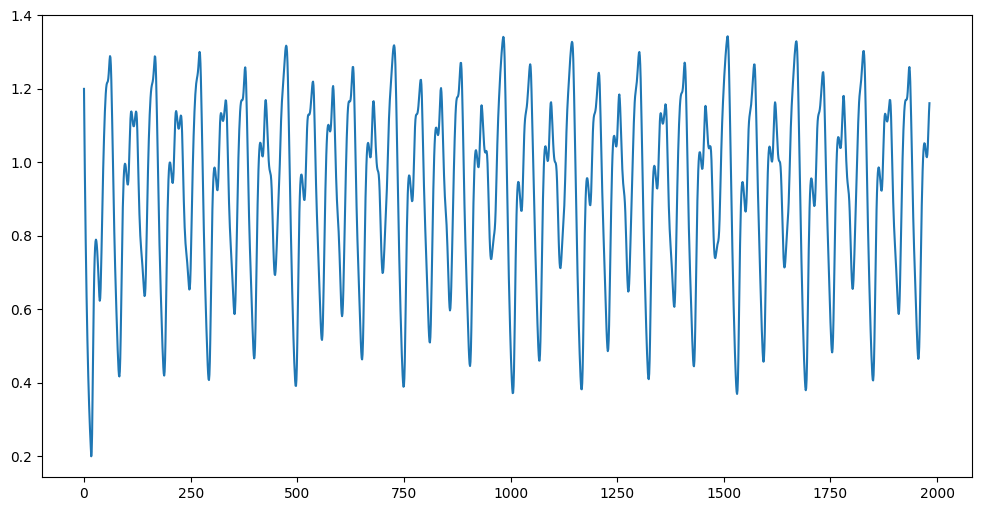

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(time_series, label="Time Series")
plt.show()

## ACF


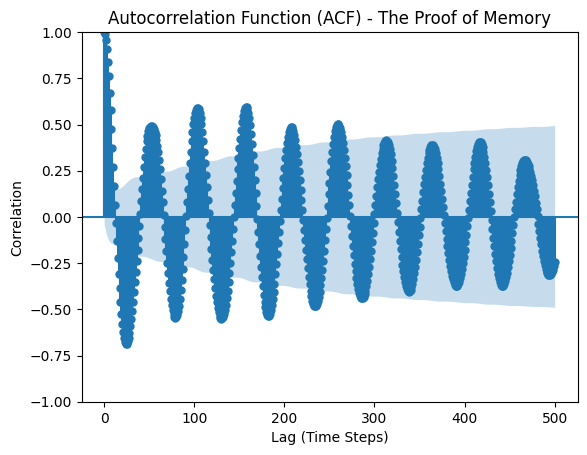

In [6]:
plot_acf(time_series, lags=500, alpha=0.05)
plt.title("Autocorrelation Function (ACF) - The Proof of Memory")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF

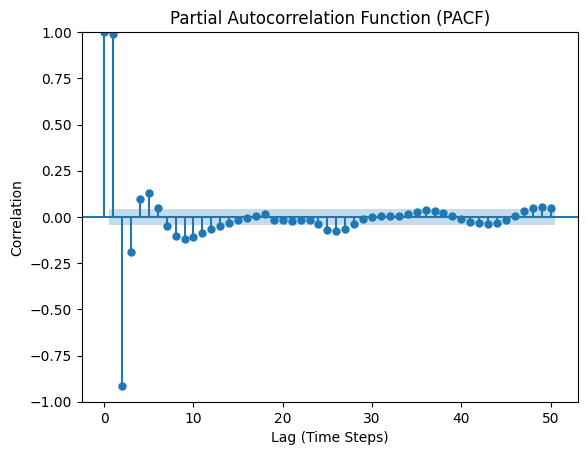

In [7]:
plot_pacf(time_series, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 0.4156


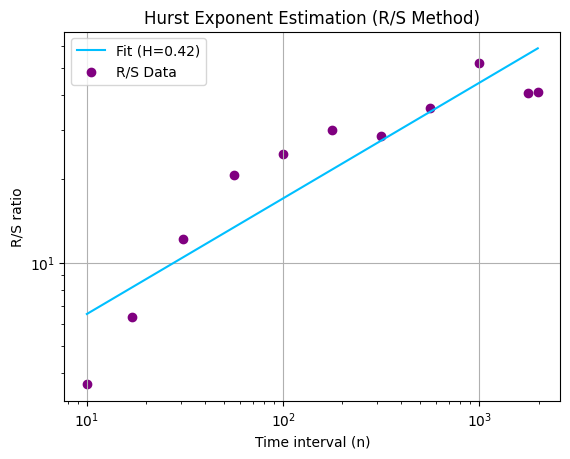

In [6]:
H, c, data = compute_Hc(time_series, kind="price", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()